In [1]:
import math
import random
import numpy as np
from math import gcd
import RSA_Module
from qiskit import QuantumCircuit
from qiskit.circuit.library import CPhaseGate
from qiskit_aer import AerSimulator

In [2]:
BIT_LENGTH = 8
#Generate private and public key
public_key, private_key = RSA_Module.generate_keypair(BIT_LENGTH)

print("Public key: ", public_key)
print("Private key: ", private_key)

Chosen primes: p = 7, q = 23
Public key:  (29, 161)
Private key:  (41, 161)


In [3]:
MESSAGE = "This is a quantum computing project"

ciphertext, encrypted_object = RSA_Module.encrypt(
    MESSAGE,
    public_key
)
print(ciphertext)


126621471381421471381421321421485913252935913514212015313521599314752122142211371531349612093


In [4]:
decrypted_msg = RSA_Module.decrypt(encrypted_object, private_key)

print("\nDecrypted message using RSA Algorithm: " + decrypted_msg)


Decrypted message using RSA Algorithm: This is a quantum computing project


In [5]:
def build_qft(num_qubits):

    qc = QuantumCircuit(num_qubits)

    for target in range(num_qubits):

        qc.h(target)

        for control in range(target + 1, num_qubits):

            angle = np.pi / (2 ** (control - target))

            qc.cp(angle, control, target)

    for i in range(num_qubits // 2):

        qc.swap(i, num_qubits - i - 1)

    return qc

In [6]:
def build_qpe(num_counting_qubits):
    """
    Build the skeleton of the Quantum Phase Estimation circuit.
    """

    total_qubits = num_counting_qubits + 1

    qc = QuantumCircuit(total_qubits, num_counting_qubits)

    return qc

In [7]:
def prepare_eigenstate(qc):
    """
    Prepare the target qubit in |1>.
    """

    qc.x(qc.num_qubits - 1)

In [8]:
def apply_hadamards(qc, num_counting_qubits):

    for qubit in range(num_counting_qubits):
        qc.h(qubit)

In [9]:
def apply_controlled_phase(qc):

    qc.cp(np.pi/4,0,3)

    qc.cp(np.pi/2,1,3)

    qc.cp(np.pi,2,3)

In [10]:
def build_phase_estimation(num_counting_qubits=3):

    qc = build_qpe(num_counting_qubits)

    prepare_eigenstate(qc)

    apply_hadamards(qc,num_counting_qubits)

    apply_controlled_phase(qc)

    inverse_qft = build_qft(num_counting_qubits).inverse()

    qc.compose(
        inverse_qft,
        qubits=range(num_counting_qubits),
        inplace=True
    )

    qc.measure(
        range(num_counting_qubits),
        range(num_counting_qubits)
    )

    return qc

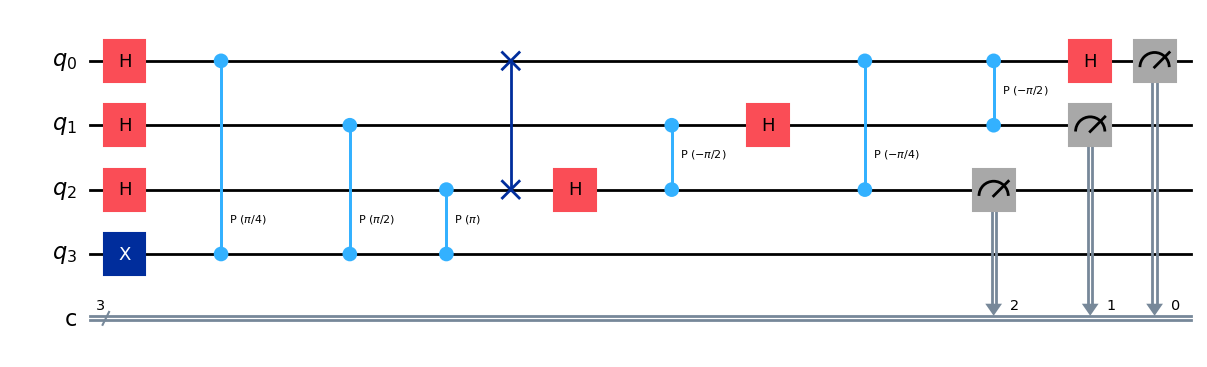

In [11]:

sim = AerSimulator()

qc = build_phase_estimation()

qc.draw("mpl")